## Load all the results into a dataframe

In [57]:
### load all results and transform
import glob
import os
import numpy as np
import pandas as pd
import scipy.stats as ss
from pathlib import Path


def make_model_column(row):
    if row['rank_loss'] == True:
        return 'rank_loss'
    if row['sdfa_ce'] == True and row['local']==False:
        return 'SDFA_notlocal'
    if row['sdfa_ce'] == True:
        return 'SDFA_local'
    if row['model'] == 'SDFA_NAP_model' and row['local']== True:
        return 'DIFF-ERO_local'
    if row['model'] == 'SDFA_NAP_model':
        return 'DIFF-ERO_notlocal'
    else:
        return 'Base'

# Load all CSVs into one big DataFrame
# -------------------------------------------------------
data_dir = Path(".")          
csv_paths = sorted(data_dir.glob("*.csv"))

dfs = []
for p in csv_paths:
    if 'nap' in str(p) and 'ns' not in str(p):
        df = pd.read_csv(p)
        df["dataset"] = p.stem
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all['model'] = df_all.apply(lambda x: make_model_column(x), axis=1)
df_all = df_all.drop(['quantile', 'max_len', 'rank_loss', 'sdfa_ce', 'no_epochs', 'er_loss'], axis=1)

df_all

,seed,local,model,lambda,d_model,batch_size,recall,precision,f1,accuracy,time,dataset
0,56,False,Base,0.0,16,32,0.550,0.796,0.600,0.550,19.329,results_nap_prediction_BPI12
1,56,False,Base,0.0,32,32,0.708,0.812,0.732,0.708,19.796,results_nap_prediction_BPI12
2,56,False,Base,0.0,64,32,0.766,0.887,0.781,0.766,21.377,results_nap_prediction_BPI12
3,56,False,DIFF-ERO_notlocal,0.1,16,32,0.685,0.830,0.724,0.685,19.705,results_nap_prediction_BPI12
4,56,False,DIFF-ERO_notlocal,0.2,16,32,0.634,0.817,0.679,0.634,19.668,results_nap_prediction_BPI12
...,...,...,...,...,...,...,...,...,...,...,...,...
5210,1089,True,SDFA_local,0.5,64,128,0.671,0.838,0.724,0.671,11.458,results_nap_prediction_BPI20TravelPermitData
5211,1089,False,SDFA_notlocal,0.5,64,128,0.666,0.919,0.737,0.666,11.608,results_nap_prediction_BPI20TravelPermitData
5212,1089,False,rank_loss,0.0,16,128,0.477,0.825,0.570,0.477,32.609,results_nap_prediction_BPI20TravelPermitData
5213,1089,False,rank_loss,0.0,32,128,0.608,0.818,0.667,0.608,32.489,results_nap_prediction_BPI20TravelPermitData


## Perform the Friedman tests

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import scikit_posthocs as sp
import scikit_posthocs as sp
from scipy.stats import rankdata
from scipy.stats import friedmanchisquare

metric = "f1"

### FIRST
df_seed_avg = (
    df_all.groupby([
        "dataset",
        "model",
        "lambda",
        "d_model",
        "batch_size",
    ])[metric]
    .mean()
    .reset_index()
)

### SECOND
best_per_seed = (
    df_seed_avg
    .sort_values("f1", ascending=False)
    .drop_duplicates(subset=["dataset",  "model"])
)

pivot = best_per_seed.pivot(
    index="dataset",
    columns="model",
    values=metric
)
pivot

ranks = pivot.apply(
    lambda row: pd.Series(
        rankdata(-row.values, method="average"),
        index=row.index
    ),
    axis=1
)
avg_ranks = ranks.mean().sort_values()
print(avg_ranks)

fcs = friedmanchisquare(*[pivot[col] for col in pivot.columns])
print(fcs)

nemenyi = sp.posthoc_nemenyi_friedman(pivot)
nemenyi

model
DIFF-ERO_local       1.833
SDFA_local           2.667
DIFF-ERO_notlocal    2.833
Base                 3.833
SDFA_notlocal        4.167
rank_loss            5.667
dtype: float64
FriedmanchisquareResult(statistic=np.float64(15.714285714285694), pvalue=np.float64(0.007708956782926438))


,Base,DIFF-ERO_local,DIFF-ERO_notlocal,SDFA_local,SDFA_notlocal,rank_loss
Base,1.000,0.432,0.940,0.889,1.000,0.533
DIFF-ERO_local,0.432,1.000,0.940,0.972,0.257,0.005
DIFF-ERO_notlocal,0.940,0.940,1.000,1.000,0.820,0.092
SDFA_local,0.889,0.972,1.000,1.000,0.734,0.061
SDFA_notlocal,1.000,0.257,0.820,0.734,1.000,0.734
rank_loss,0.533,0.005,0.092,0.061,0.734,1.000


## Nemenyi Plots

model
DIFF-ERO_local       1.833
SDFA_local           2.667
DIFF-ERO_notlocal    2.833
Base                 3.833
SDFA_notlocal        4.167
rank_loss            5.667
dtype: float64


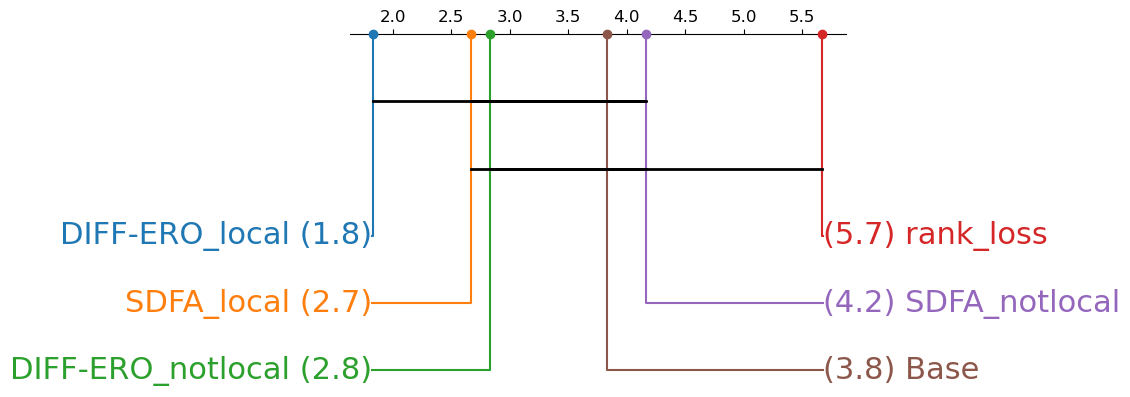

In [59]:
ranks = pivot.apply(
    lambda row: pd.Series(
        rankdata(-row.values, method="average"),
        index=row.index
    ),
    axis=1
)

avg_ranks = ranks.mean().sort_values()
print(avg_ranks)

plt.rcParams.update({
    'font.size': 22,          # default text size
    'axes.titlesize': 18,     # title
    'axes.labelsize': 16,     # x‑ and y‑labels
    'xtick.labelsize': 12,    # x‑tick labels
    'ytick.labelsize': 12,    # y‑tick labels
    'legend.fontsize': 12,    # legend
})


sp.critical_difference_diagram(avg_ranks, nemenyi)
plt.show()

## Additional Shaffer test

model
DIFF-ERO_local       1.833
SDFA_local           2.667
DIFF-ERO_notlocal    2.833
Base                 3.833
SDFA_notlocal        4.167
rank_loss            5.667
dtype: float64
                   meanrank   mean    std ci_lower ci_upper effect_size  \
rank_loss             5.667  0.771  0.101      NaN      NaN         0.0   
SDFA_notlocal         4.167  0.782  0.105      NaN      NaN       -0.11   
Base                  3.833  0.811  0.082      NaN      NaN      -0.444   
DIFF-ERO_notlocal     2.833  0.827  0.075      NaN      NaN      -0.629   
SDFA_local            2.667  0.804  0.101      NaN      NaN      -0.327   
DIFF-ERO_local        1.833  0.830  0.078      NaN      NaN      -0.662   

                    magnitude effect_size_above magnitude_above  
rank_loss          negligible               0.0      negligible  
SDFA_notlocal      negligible             -0.11      negligible  
Base                    small            -0.314           small  
DIFF-ERO_notlocal      medi

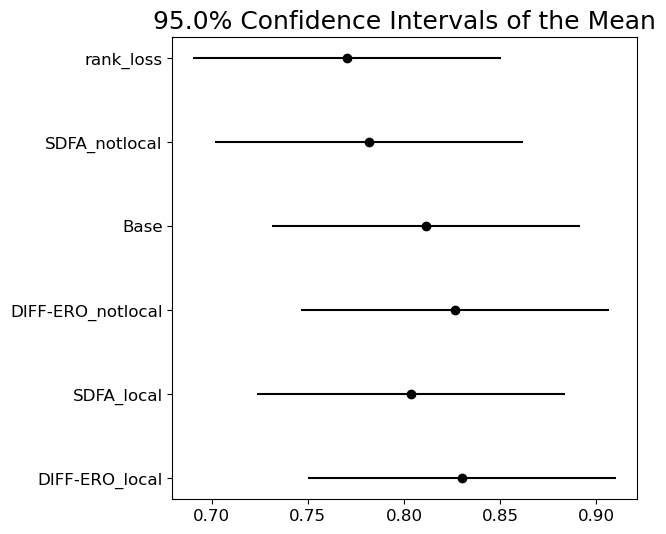

In [70]:
import scikit_posthocs as sp
import pandas as pd
import numpy as np
from scipy.stats import rankdata, friedmanchisquare

# --- Ranks (unchanged) ---
ranks = pivot.apply(
    lambda row: pd.Series(
        rankdata(-row.values, method="average"),
        index=row.index
    ),
    axis=1
)
avg_ranks = ranks.mean().sort_values()
print(avg_ranks)

# --- Shaffer's post-hoc test ---
# scikit_posthocs expects shape (datasets x classifiers)
shaffer = sp.posthoc_nemenyi_friedman(pivot)  # get p-value matrix first


# Apply Shaffer's correction to the p-value matrix
n_comparisons = shaffer.shape[0]
pvals = shaffer.values[np.triu_indices(n_comparisons, k=1)]  # upper triangle

from itertools import combinations
labels = shaffer.columns.tolist()
pairs = list(combinations(labels, 2))

# Shaffer's static correction
shaffer_corrected = sp.posthoc_dunn(pivot.values)   # placeholder shape
# shaffer_result = sp.posthoc_nemenyi_friedman(pivot)
shaffer_result = sp.posthoc_nemenyi_friedman(pivot.values)

# Restore classifier names to the result matrix
shaffer_result.index = pivot.columns
shaffer_result.columns = pivot.columns

# The cleanest path: use autorank which implements Shaffer natively
# pip install autorank
from autorank import autorank, plot_stats, create_report

result = autorank(pivot, alpha=0.05, verbose=False)

# --- Plot ---
plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

plot_stats(result)
plt.show()

## Full results

In [63]:
import glob
import os
import pandas as pd
import scipy.stats as ss
from pathlib import Path

# -------------------------------------------------------
# 1. Load all CSVs into one big DataFrame
# -------------------------------------------------------
data_dir = Path(".")          # <-- change this
csv_paths = sorted(data_dir.glob("*.csv"))

dfs = []
for p in csv_paths:
    if 'nap' in str(p) and 'ns' not in str(p):
        df = pd.read_csv(p)
        # Keep the source dataset name (file stem)
        df["dataset"] = p.stem
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

# -------------------------------------------------------
# 2. Basic filtering
# -------------------------------------------------------
df_all = df_all[df_all["lambda"] < 0.5]
# df_all = df_all[df_all['local'] == False]

# -------------------------------------------------------
# 3. Keep only the metrics we care about
# -------------------------------------------------------
cols_needed = ["dataset", "seed", "model", "d_model", 'sdfa_ce', 'rank_loss', "lambda", "f1", "precision"]
df_all = df_all[cols_needed]

# -------------------------------------------------------
# 4. Find the best parameter setting per seed–model–dataset
# -------------------------------------------------------
best = (
    df_all
    .sort_values("f1", ascending=False)          # highest f1 first
    .drop_duplicates(subset=["dataset", "seed", "model", 'sdfa_ce', 'rank_loss',], keep="first")
    .reset_index(drop=True)
)

# -------------------------------------------------------
# 5. Average metrics over seeds, grouped by dataset & model
# -------------------------------------------------------
summary = (
    best
    .groupby(["dataset", "model", 'sdfa_ce', 'rank_loss',], as_index=False)
    .agg(
        f1_mean=("f1", "mean"),
        precision_mean=("precision", "mean")
    )
)

# -------------------------------------------------------
# 6. Pivot so that each model becomes a column
# -------------------------------------------------------
pivot_f1 = summary.pivot(index="dataset", columns=["model", 'sdfa_ce', 'rank_loss'], values=["f1_mean",'precision_mean'])
# pivot_prec = summary.pivot(index="dataset", columns="model", values="precision_mean")
pd.set_option("display.precision", 3)
pivot_f1

f1_mean         \
model                                          NAP_model          
sdfa_ce                                            False          
rank_loss                                          False  True    
dataset                                                           
results_nap_prediction_BPI12                       0.786  0.716   
results_nap_prediction_BPI17                       0.823  0.795   
results_nap_prediction_BPI19                       0.722  0.735   
results_nap_prediction_BPI20PrepaidTravelCosts     0.855  0.818   
results_nap_prediction_BPI20RequestForPayment      0.948  0.948   
results_nap_prediction_BPI20TravelPermitData       0.808  0.737   

                                                                      \
model                                          SDFA_NAP_model          
sdfa_ce                                                 False  True    
rank_loss                                               False  False   
dataset                                                                
results_nap_prediction_BPI12                            0.821  0.715   
results_nap_prediction_BPI17                            0.863  0.824   
results_nap_prediction_BPI19                            0.789  0.759   
results_nap_prediction_BPI20PrepaidTravelCosts          0.890  0.887   
results_nap_prediction_BPI20RequestForPayment           0.949  0.949   
results_nap_prediction_BPI20TravelPermitData            0.862  0.853   

                                               precision_mean         \
model                                               NAP_model          
sdfa_ce                                                 False          
rank_loss                                               False  True    
dataset                                                                
results_nap_prediction_BPI12                            0.878  0.830   
results_nap_prediction_BPI17                            0.895  0.883   
results_nap_prediction_BPI19                            0.918  0.914   
results_nap_prediction_BPI20PrepaidTravelCosts          0.939  0.936   
results_nap_prediction_BPI20RequestForPayment           0.990  0.989   
results_nap_prediction_BPI20TravelPermitData            0.906  0.884   

                                                                      
model                                          SDFA_NAP_model         
sdfa_ce                                                 False  True   
rank_loss                                               False  False  
dataset                                                               
results_nap_prediction_BPI12                            0.877  0.863  
results_nap_prediction_BPI17                            0.900  0.902  
results_nap_prediction_BPI19                            0.914  0.914  
results_nap_prediction_BPI20PrepaidTravelCosts          0.944  0.955  
results_nap_prediction_BPI20RequestForPayment           0.990  0.990  
results_nap_prediction_BPI20TravelPermitData            0.925  0.926

In [64]:
import glob
import os
import pandas as pd
import scipy.stats as ss
from pathlib import Path

# -------------------------------------------------------
# 1. Load all CSVs into one big DataFrame
# -------------------------------------------------------
data_dir = Path(".")          # <-- change this
csv_paths = sorted(data_dir.glob("*.csv"))

def make_model_column(row):
    if row['rank_loss'] == True:
        return 'rank_loss'
    if row['sdfa_ce'] == True and row['local']==False:
        return 'SDFA_notlocal'
    if row['sdfa_ce'] == True:
        return 'SDFA_local'
    if row['model'] == 'SDFA_NAP_model' and row['local']== True:
        return 'DIFF-ERO_local'
    if row['model'] == 'SDFA_NAP_model':
        return 'DIFF-ERO_notlocal'
    else:
        return 'Base'

dfs = []
for p in csv_paths:
    if 'nap' in str(p) and 'ns' not in str(p):
        df = pd.read_csv(p)
        # Keep the source dataset name (file stem)
        df["dataset"] = p.stem
        dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all['model'] = df_all.apply(lambda x: make_model_column(x), axis=1)

# -------------------------------------------------------
# 2. Basic filtering
# -------------------------------------------------------
df_all = df_all[df_all["lambda"] < 0.5]
# df_all = df_all[df_all['local'] == False]

# -------------------------------------------------------
# 3. Keep only the metrics we care about
# -------------------------------------------------------
cols_needed = ["dataset", "seed", "model", "d_model", 'sdfa_ce', 'rank_loss', "lambda", "f1", "precision"]
df_all = df_all[cols_needed]

# -------------------------------------------------------
# 4. Find the best parameter setting per seed–model–dataset
# -------------------------------------------------------
best = (
    df_all
    .sort_values("f1", ascending=False)          # highest f1 first
    .drop_duplicates(subset=["dataset", "seed", "model", 'sdfa_ce', 'rank_loss',], keep="first")
    .reset_index(drop=True)
)

# -------------------------------------------------------
# 5. Average metrics over seeds, grouped by dataset & model
# -------------------------------------------------------
summary = (
    best
    .groupby(["dataset", "model", 'sdfa_ce', 'rank_loss',], as_index=False)
    .agg(
        f1_mean=("f1", "mean"),
        precision_mean=("precision", "mean")
    )
)

# -------------------------------------------------------
# 6. Pivot so that each model becomes a column
# -------------------------------------------------------
pivot_f1 = summary.pivot(index="dataset", columns=["model", 'sdfa_ce', 'rank_loss'], values=["f1_mean",'precision_mean'])
# pivot_prec = summary.pivot(index="dataset", columns="model", values="precision_mean")
pd.set_option("display.precision", 3)
pivot_f1

f1_mean                 \
model                                             Base DIFF-ERO_local   
sdfa_ce                                          False          False   
rank_loss                                        False          False   
dataset                                                                 
results_nap_prediction_BPI12                     0.786          0.819   
results_nap_prediction_BPI17                     0.823          0.863   
results_nap_prediction_BPI19                     0.722          0.772   
results_nap_prediction_BPI20PrepaidTravelCosts   0.855          0.890   
results_nap_prediction_BPI20RequestForPayment    0.948          0.948   
results_nap_prediction_BPI20TravelPermitData     0.808          0.860   

                                                                             \
model                                          DIFF-ERO_notlocal SDFA_local   
sdfa_ce                                                    False      True    
rank_loss                                                  False      False   
dataset                                                                       
results_nap_prediction_BPI12                               0.810      0.714   
results_nap_prediction_BPI17                               0.841      0.824   
results_nap_prediction_BPI19                               0.755      0.751   
results_nap_prediction_BPI20PrepaidTravelCosts             0.851      0.886   
results_nap_prediction_BPI20RequestForPayment              0.948      0.949   
results_nap_prediction_BPI20TravelPermitData               0.845      0.853   

                                                                        \
model                                          SDFA_notlocal rank_loss   
sdfa_ce                                                True      False   
rank_loss                                              False     True    
dataset                                                                  
results_nap_prediction_BPI12                           0.666     0.716   
results_nap_prediction_BPI17                           0.798     0.795   
results_nap_prediction_BPI19                           0.738     0.735   
results_nap_prediction_BPI20PrepaidTravelCosts         0.874     0.818   
results_nap_prediction_BPI20RequestForPayment          0.949     0.948   
results_nap_prediction_BPI20TravelPermitData           0.795     0.737   

                                               precision_mean                 \
model                                                    Base DIFF-ERO_local   
sdfa_ce                                                 False          False   
rank_loss                                               False          False   
dataset                                                                        
results_nap_prediction_BPI12                            0.878          0.877   
results_nap_prediction_BPI17                            0.895          0.900   
results_nap_prediction_BPI19                            0.918          0.910   
results_nap_prediction_BPI20PrepaidTravelCosts          0.939          0.945   
results_nap_prediction_BPI20RequestForPayment           0.990          0.990   
results_nap_prediction_BPI20TravelPermitData            0.906          0.923   

                                                                             \
model                                          DIFF-ERO_notlocal SDFA_local   
sdfa_ce                                                    False      True    
rank_loss                                                  False      False   
dataset                                                                       
results_nap_prediction_BPI12                               0.882      0.866   
results_nap_prediction_BPI17                               0.895      0.902   
results_nap_prediction_BPI19                               0.913      0.913   
results_nap_prediction_BPI20PrepaidTravelCost